# Explain Step Tutorial


## What you'll learn
1. Theory Primer <br>
2. How to run explain step <br>
3. How to customize the explain step <br>
4. Using LLMs to get biological insights of the latent dimensions <br>

### 1) Theory Primer
TODO

### 2) How To Perform the Explain Step
First, we need to run an AUTOENCODIX pipeline, `Ontix` is a very good choice here.
#### ❗❗ Requirements: Getting Tutorial Data ❗❗
To follow along, please download the date from the link below (1GB):

https://cloud.scadsai.uni-leipzig.de/index.php/s/QXYnieKY8AA3Zta/download/OntixTutorialData.zip

After downloading:
- from the root of the repository, create the folders `data/raw` if not created yet
- move the donwloaded files there

#### Extra 2: Get correct path
We assume you are in the root of the package. The following code ensures that the correct paths are used.
[1] Tutorials/DeepDives/ConfigTutorial.ipynb


In [1]:
# Setting CUBLAS for reproducibility if you train on GPU
%env CUBLAS_WORKSPACE_CONFIG=:16:8

env: CUBLAS_WORKSPACE_CONFIG=:16:8


In [2]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")


Changed to: /home/ewald/Github/autoencodix_package


### 2a) Creating a synthetic ground truth
Feature importance by attribution scores is hard to quantify for its performance and reliability of outcome. Hence, we will introduce in this tutorial a little synthetic signal on selected genes of a specific chromosome only for a group of sample to check if they will be picked up by our xAI method.
Hence, we will alter the gene expression and methylation intensities of some genes of the 21 Chromosome only for 'male' samples (compare also Ontix tutorial).

In [3]:
import numpy as np
import pandas as pd
### Test with synthetic signal ###

def synth_signal(df, feature_list, sample_list):
	max_q90 = df.stack().quantile(0.9) # Our signal expression
	for sample in sample_list:
			df.loc[sample, feature_list] = max_q90*4 + np.random.normal(loc=0, scale=max_q90 * 0.25) # Add some noise to the signal
	return df

# Some genes on chromosome 21 which we will alter
# be aware that some will be filtered out during preprocessing by variance filtering
feature_synth = [
	"102724219",	# 21:p12
	"105379499",	# 21:p12
	"246312",	# 21:q21.1
	"105372749",	# 21:q21.2
	"266917",	# 21:q21.2
	"5651",	# 21:q21.1
	"105369292",	# 21:q21.1
	"102724951",	# 21:p11.2
	"1525",	# 21:q21.1
	"101927843",	# 21:q21.1
	"378828",	# 21:q21.1
	"118421",	# 21:q21.3
	"284825",	# 21:q21.3
	"101927869",	# 21:q21.2
	"9875",	# 21:q22.11
	"100874059",	# 13:q12.3
	"100131902",	# 21:q22.11
	"58494",	# 21:q21.3
	"105372746",	# 21:q21.1
]

df_rna = pd.read_parquet("data/raw/"+"combined_rnaseq_formatted.parquet")
df_meth = pd.read_parquet("data/raw/"+"combined_meth_formatted.parquet")
df_anno = pd.read_parquet("data/raw/"+"combined_clin_formatted.parquet")

sample__intersection = df_rna.index.intersection(df_meth.index).intersection(df_anno.index)
sample_group = "Male"
sample_synth = df_anno.loc[df_anno["SEX"] == sample_group].index.intersection(sample__intersection).to_list()

df_rna = synth_signal(df_rna, feature_list=feature_synth, sample_list=sample_synth)
df_meth = synth_signal(df_meth, feature_list=feature_synth, sample_list=sample_synth)

# Save the modified dataframes
df_rna.to_parquet("data/raw/"+"combined_rnaseq_formatted_synth.parquet")
df_meth.to_parquet("data/raw/"+"combined_meth_formatted_synth.parquet")

We can check the result by plotting the gene expression distribution for the altered features (genes):

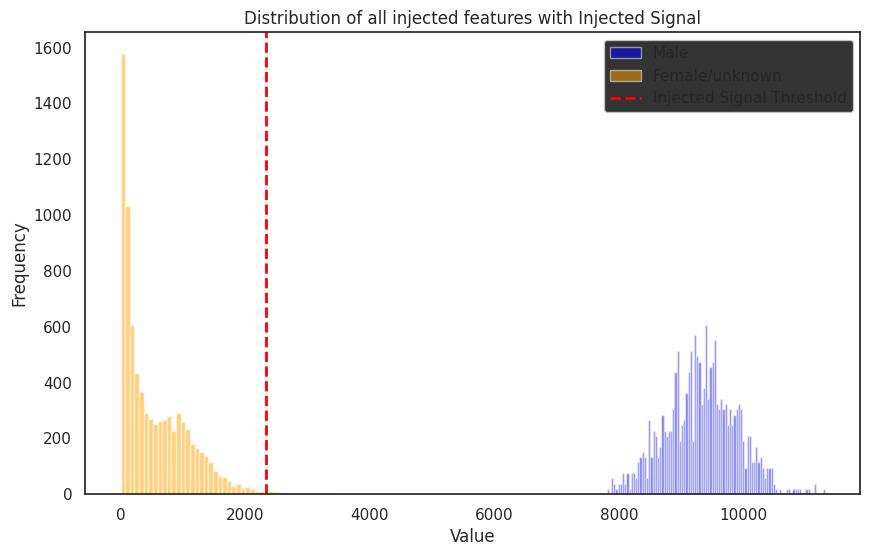

In [26]:
# Plot the distribution of the modified features compared to all features
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_rna.loc[sample_synth,feature_synth].stack(), bins=100, alpha=0.5, label="Male", color="blue")
plt.hist(df_rna.loc[~df_rna.index.isin(sample_synth), feature_synth].stack(), bins=100, alpha=0.5, label="Female/unknown", color="orange")
# plt.hist(df_meth[feature], bins=50, alpha=0.5, label="Methylation", color="orange")
# plt.hist(df_rna.drop(columns=feature_synth).values.flatten(), bins=100, alpha=0.2, label="Other RNA-seq Features", color="blue")
plt.axvline(
	df_rna.stack().quantile(0.9),
	color="red",
	linestyle="dashed",
	linewidth=2,
	label="Injected Signal Threshold",
)
plt.title(f"Distribution of all injected features with Injected Signal")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 2b) Train an Ontix on the data set with synthetic signal.

In [5]:
import os
import autoencodix as acx
from autoencodix.configs.default_config import DataConfig, DataInfo, DataCase
from autoencodix.configs import OntixConfig

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
data_root = "data/raw"
# rna_file = "combined_rnaseq_formatted.parquet"
# meth_file = "combined_meth_formatted.parquet"
# clin_file = "combined_clin_formatted.parquet"
rna_file = "combined_rnaseq_formatted_synth.parquet"
meth_file = "combined_meth_formatted_synth.parquet"
clin_file = "combined_clin_formatted.parquet"
ont_genelevel = "chromosome_ont_genelevel_ncbi.txt"
ont_hiddenlevel = "chromosome_ont_hiddenlevel.txt"
# ---------------------------------------------------------------------
# Define individual data modalities
# ---------------------------------------------------------------------
rna_info = DataInfo(
    file_path=os.path.join(data_root, rna_file),
    data_type="NUMERIC",
    filtering="VAR",
)

meth_info = DataInfo(
    file_path=os.path.join(data_root, meth_file),
    data_type="NUMERIC",
    filtering="VAR",
)

anno_info = DataInfo(
    file_path=os.path.join(data_root, clin_file),
    data_type="ANNOTATION",
)
# ---------------------------------------------------------------------
# Combine into DataConfig
# ---------------------------------------------------------------------
data_config = DataConfig(
    data_info={
        "RNA": rna_info,
        "METH": meth_info,
        "ANNO": anno_info,
    },
    annotation_columns=[
        # "CANCER_TYPE",
        "CANCER_TYPE_ACRONYM",
        # "TMB_NONSYNONYMOUS",
        # "AGE",
        # "OS_STATUS",
        # "GRADE",
        "SEX",
    ],
)

# ---------------------------------------------------------------------
# Define the full DefaultConfig (roughly equivalent to old cfg)
# ---------------------------------------------------------------------
ontix_config = OntixConfig(
    data_config=data_config,
    reproducible=True,
    global_seed=42,
    epochs=100,
    learning_rate=0.0005,
    batch_size=128,
    drop_p=0.3,
    k_filter=2000,
    latent_dim=6,
    # device="cpu",
    device="cuda",
    reconstruction_loss="mse",
    default_vae_loss="kl",
    beta=0.001,
    save_memory=False,
    scaling="MINMAX",
    train_ratio=0.7,
    test_ratio=0.2,
    valid_ratio=0.1,
)

# ---------------------------------------------------------------------
# Now pass into your Ontix object
# ---------------------------------------------------------------------

ont_files = [ont_hiddenlevel, ont_genelevel]
ont_files = [os.path.join(data_root, f) for f in ont_files]
ontix = acx.Ontix(
    ontologies=ont_files,
    config=ontix_config,
)

In [6]:
result = ontix.run()

reading parquet: data/raw/combined_rnaseq_formatted_synth.parquet
reading parquet: data/raw/combined_meth_formatted_synth.parquet
reading parquet: data/raw/combined_clin_formatted.parquet
anno key: paired
Features in feature_order not found in all_feature_names: ['100133144', '10357', '10431', '155060', '390284', '57714', '645851', '653553', '729884', '246182', '119385', '653268', '728404', '200810', '138649', '441425', '728747', '729171', '23520', '303', '304', '305', '244', '375719', '441432', '503640', '641522', '432369', '92270', '6791', '85319', '606', '23629', '286076', '414235', '170393', '255352', '283422', '283416', '374467', '84837', '400223', '650662', '280655', '283651', '80035', '283687', '196968', '284185', '147429', '147525', '494514', '574036', '284573', '149469', '84791', '253868', '284836', '54094', '54067', '282566', '114041', '114043', '149992', '55267', '29798', '348738', '339942', '93556', '646450', '317648', '92070', '79614', '153571', '116349', '441108', '285679

### Check if we have a little signal on Chromosome 21 (male/femal seperation)

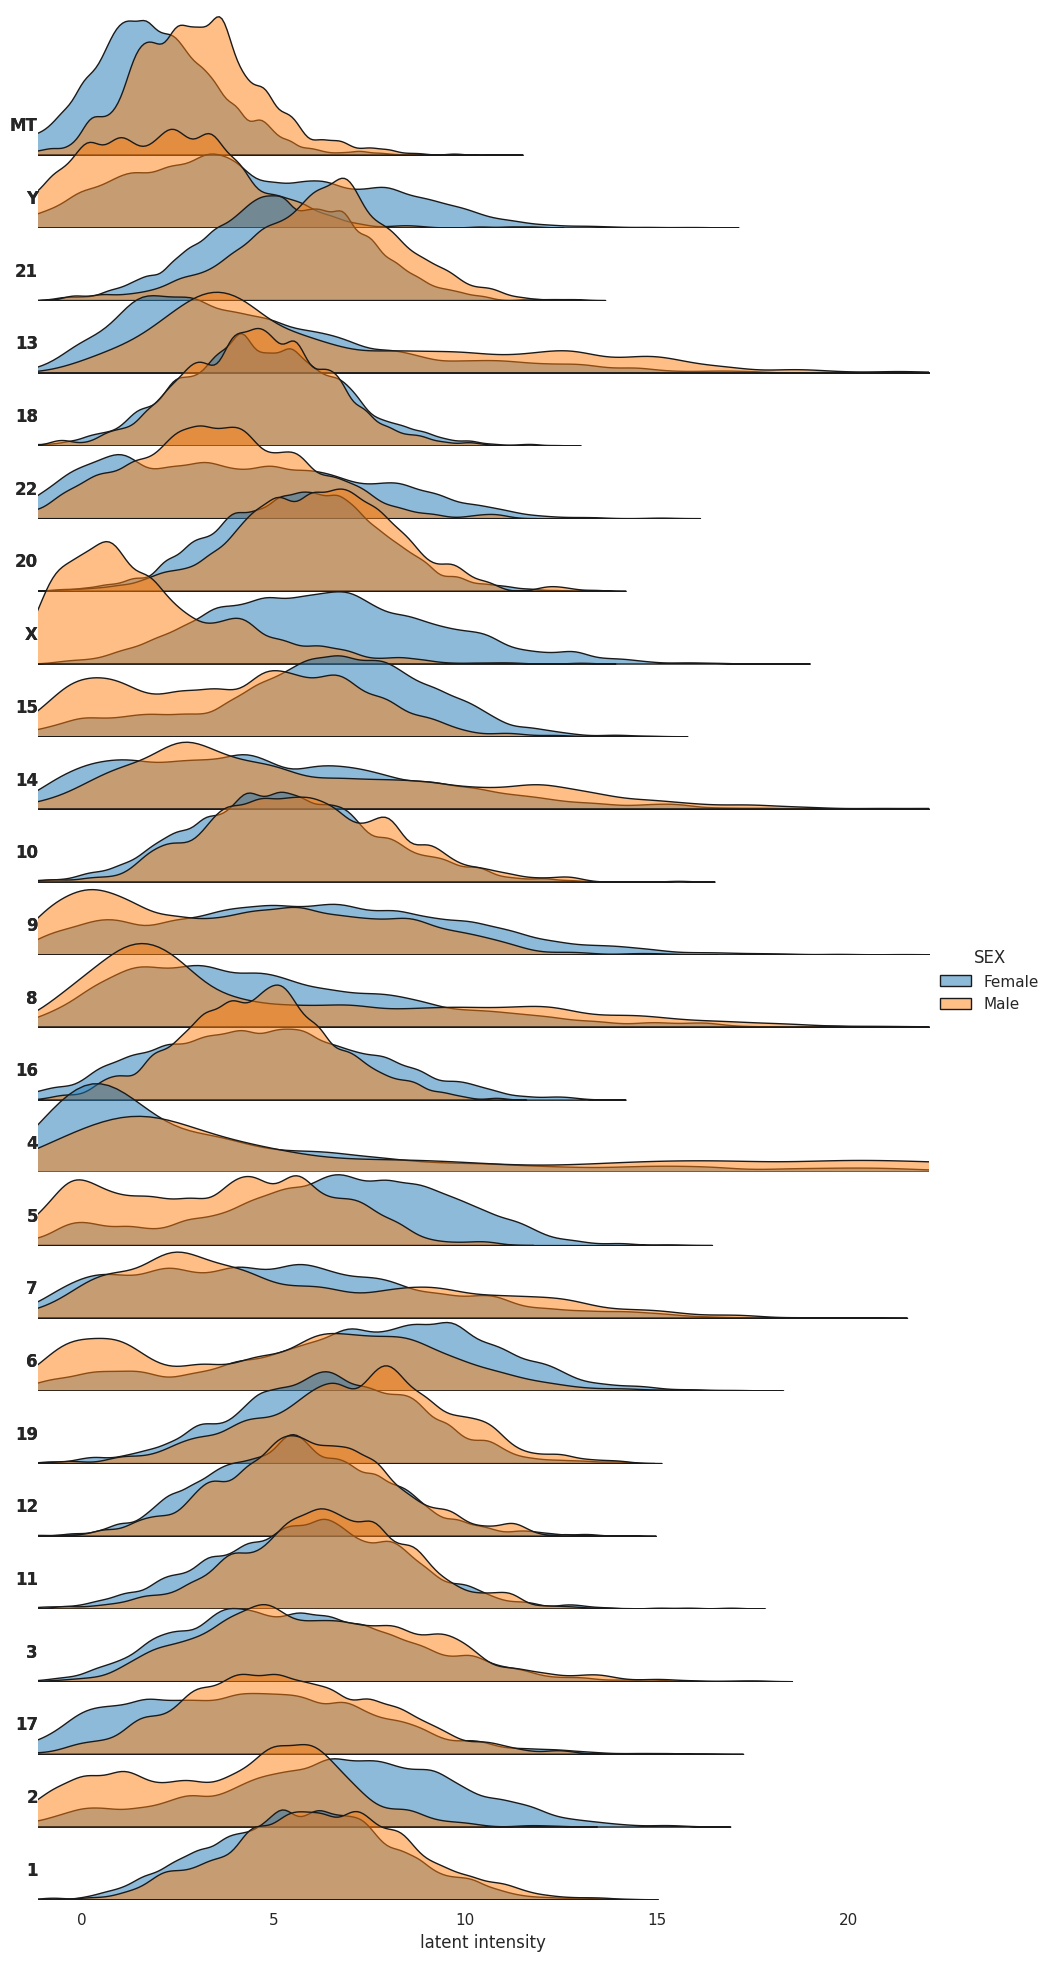

In [28]:
# ontix.show_result(params=["SEX"])
ontix.visualizer.show_latent_space(result=ontix.result, plot_type="Ridgeline", param=["SEX"])

##### Now we can call ontix.explain()
This will calculate gene-by-latent-dimension attribution scores. The explain step returns these as pd.DataFrame and also saves this DataFrame to `result.embedding_attributions`

In [30]:
# latent_contributions = ontix.explain()
latent_contributions = ontix.explain(
    method="DeepLiftShap", # "DeepLiftShap" or "IntegratedGradients"
    sel_latent_dim=None, # To calculate contribution for all latent dimensions
    # sel_latent_dim='21', # Or specify a single latent dimension to explain
	input_type="grouped", # We will test group 'Male' (input) vs. 'Female' (baseline)
	input_group="Male",
	baseline_type="grouped",
	baseline_group="Female",
	anno_col="SEX",
)

In [31]:
print(latent_contributions)

             MT         Y        21        13        18        22        20  \
8755   0.000359  0.000701  0.000661  0.001642  0.000337  0.000228  0.000944   
6439   0.000076  0.000629  0.000063  0.000744  0.000355  0.000573  0.000087   
1277   0.000350  0.000440  0.000324  0.000817  0.000485  0.001009  0.000112   
3481   0.000034  0.000010  0.000067  0.000038  0.000045  0.000065  0.000045   
2335   0.000236  0.001519  0.000884  0.001782  0.000162  0.000698  0.000518   
...         ...       ...       ...       ...       ...       ...       ...   
63974  0.004243  0.003958  0.005720  0.001547  0.006212  0.008114  0.004660   
7681   0.001360  0.003288  0.003869  0.005236  0.000862  0.001017  0.002697   
2882   0.004272  0.000770  0.005517  0.014458  0.004972  0.003136  0.006881   
7092   0.001581  0.005974  0.003545  0.023420  0.001217  0.007110  0.005496   
10     0.009802  0.020023  0.010137  0.010909  0.019276  0.029989  0.009919   

              X        15        14  ...         5 

In [41]:
latent_contributions.loc[:, ["21"]].sort_values(by="21", ascending=False)

,21
1525,3.408980e-02
9875,3.298643e-02
1525,3.155649e-02
58494,3.081555e-02
9185,2.071157e-02
...,...
58,9.405823e-07
10321,9.131665e-07
1548,5.554035e-07
3848,3.898093e-07


#### Now we can plot top 10 highest contribution scores of chromosome 21 and highlight features with synthetic signal
We see indeed that our groundtruth signal genes show the highest attribution scores


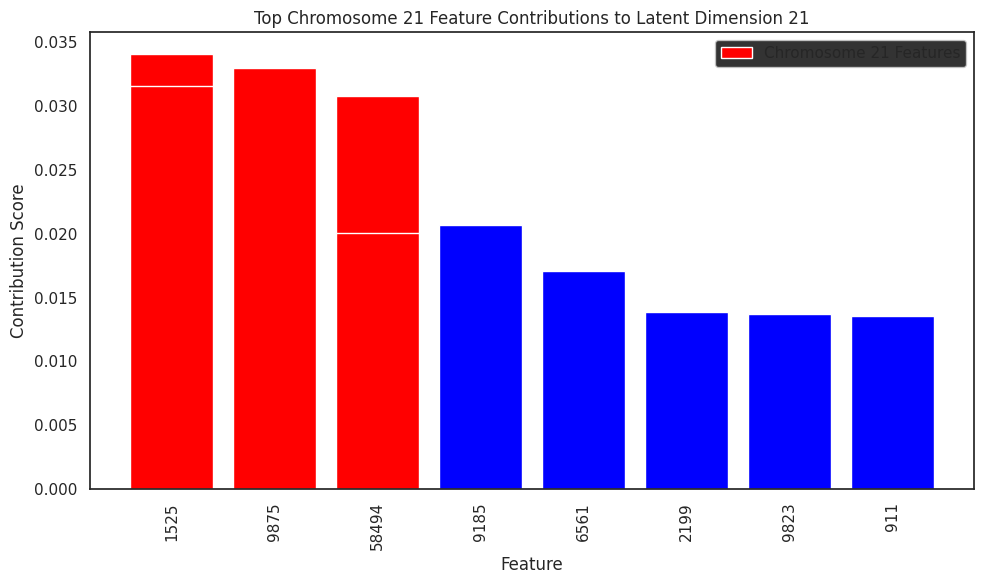

In [57]:
chrom_21_contributions = latent_contributions.loc[:, ["21"]].sort_values(by="21", ascending=False)[:10]

color_map = ["red" if feature in feature_synth else "blue" for feature in chrom_21_contributions.index]

plt.figure(figsize=(10, 6))
plt.bar(chrom_21_contributions.index, chrom_21_contributions.values.flatten(), color=color_map, label="Chromosome 21 Features")
plt.title("Top Chromosome 21 Feature Contributions to Latent Dimension 21")
plt.xlabel("Feature")
plt.ylabel("Contribution Score")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


        
### 3) How to Customize the Explain Step 
TODO Vincent explain, besser
You have the follwong options:
```python
        method: Literal["DeepLiftShap", "IntegratedGradients"] = "DeepLiftShap",
        baseline_type: Literal["mean", "random_sample"] = "mean",
        baseline_group: str = "all",
        obs_col: Optional[str] = None,
        n_subset: int = 100,
        seed_int: int = 12,
        split: Literal["train", "test", "valid"] = "train",
        llm_explain: bool = False,
        llm_client: Literal["ollama", "mistral"] = "mistral",
        llm_model: str = "mistral-large-latest",
        top_n_genes: int = 40,
        prompt: str = PROMPT,
```

**More Details on the Options:**

```python
        """Runs the feature-importance explainer and returns gene-by-latent-dimension attribution scores.

        Args:
            method:  Specifies which attribution algorithm to use for explaining the model.
            baseline_type: Specifies whether the feature-importance algorithm should use the mean baseline or a random-sample baseline.
            baseline_group: Specifies whether the baseline is computed using all data (default) or which subset in obs_col to filter for.
            obs_col: If baseline_group is not 'all', this specifies the observation column used to filter the baseline data.
            n_subset: Specifies the number of cells to use when subsampling for the attribution computation.
            seed_int: Defines the random seed used for reproducible subsampling and attribution calculations.
            split: The split to use for feature importance calculation (train, valid, test), default is train.
            llm_explain: Whether to use LLM explainers for feature importance calculation.
            llm_client: The LLM client to use for feature importance calculation.
            llm_model: The LLM model to use for feature importance calculation.
            top_n_genes: How many top (contribution to embedding) genes to consider for LLM explanation.

        Returns:
            pd.DataFrame: The generated samples in the input space.
                A DataFrame of attribution scores with genes as the index and latent dimensions as columns.
                Each entry represents the contribution of a given gene to a specific latent dimension.
        """
        ```

### 4) How To Use LLM to Get Insights of Gene Contributions
We can send the gene attribution score directly to an LLM and get biological insights for each latent dimension, i.e. latent dim 1 is associated with cell cylce ..
The LLM will give you and explanation for each latent dim and will save this in an extra markdown file. Additionally, we get  parsable JSON that is stored in `result.embedding_explanations`.  

Before, we can obtain this, we need to set up our LLM provider (in the future this might be provided by use)
See below how to do  this:


#### 🧬 Gene Expression Explanation – README
You can get LLM explanations from our  `.explain` step by setting `llm_explain=True`. Therefore you need to setup LLM Clients

You can use either:

* **Mistral API** (cloud-based)
* **Ollama** (local models running on your machine)



#### Requirements

Depending on if you want to use Mistral or Ollama you need to have:
- a Mistral API key
- Ollam installed and at least one model served


#### Environment Setup

##### 1. Using Mistral API

Set an API key in your `.env` file in the root of the repository

```
MISTRAL_API_KEY=your_api_key_here
```

**Models**

You may use any model served by Mistral, for example:

* `mistral-small-latest`
* `mistral-medium-latest`
* `mistral-large-latest`

Make sure the `model_name` you pass to `.explain` matches an available Mistral model.


##### 2. Using Ollama

Ollama runs models **locally**.
You must first install Ollama and pull the model you want:

```bash
ollama pull <model-name>
```


Your `model_name` must match exactly the name of the model served by Ollama:

* `qwen2.5:0.5b`
* `deepseek-r1:8b`


##### 🧬 Using `.explain()` for Gene Expression Interpretation

The `.explain()` method can generate a short biological explanation and hypothesis about what is happening in disease vs healthy samples given a list of altered genes.

### Example


In [10]:

ontix.explain(llm_explain=True, llm_client="ollama", llm_model="gemma3:1b", top_n_genes=5)

Saved explanations to: /home/ewald/Github/autoencodix_package/latent_explanations.md


,MT,Y,21,13,18,22,20,X,15,14,...,5,7,6,19,12,11,3,17,2,1
8755,0.000220,0.001330,0.000955,0.000818,0.001146,0.003158,0.003306,0.001162,0.001361,0.000534,...,0.000673,0.000576,0.000713,0.000603,0.000568,0.000925,0.000756,0.000738,0.003567,0.001349
6439,0.000687,0.000998,0.000521,0.000415,0.000397,0.001075,0.000790,0.000791,0.000346,0.000849,...,0.001838,0.001465,0.001053,0.001209,0.001014,0.000736,0.000837,0.000621,0.001098,0.000823
1277,0.000284,0.000441,0.000381,0.000297,0.000586,0.000972,0.000769,0.001094,0.000332,0.000402,...,0.000516,0.000520,0.000362,0.000451,0.000351,0.000534,0.000369,0.000288,0.001149,0.000385
2335,0.000562,0.000436,0.000502,0.000369,0.000418,0.000625,0.000633,0.000608,0.000309,0.000634,...,0.001299,0.001332,0.000680,0.000867,0.000661,0.000273,0.000836,0.000314,0.000877,0.000784
3481,0.000104,0.000248,0.000197,0.000120,0.000154,0.000716,0.001015,0.000332,0.000416,0.000106,...,0.000202,0.000293,0.000115,0.000116,0.000091,0.000138,0.000180,0.000089,0.000812,0.000411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3747,0.002205,0.005309,0.001923,0.002425,0.006223,0.002816,0.008842,0.006151,0.003759,0.004047,...,0.014143,0.010548,0.002184,0.002678,0.002068,0.003910,0.002134,0.002281,0.004091,0.002136
51050,0.004277,0.001719,0.008964,0.008355,0.008838,0.001821,0.014251,0.003235,0.009163,0.004737,...,0.005204,0.001707,0.007258,0.008312,0.007404,0.007803,0.009754,0.006967,0.002954,0.008994
140679,0.000880,0.004253,0.001189,0.001160,0.005632,0.004215,0.004318,0.003020,0.001656,0.003795,...,0.012723,0.009629,0.001756,0.002290,0.001612,0.003011,0.002239,0.001482,0.005050,0.002177
126308,0.003883,0.003664,0.005673,0.003166,0.002020,0.003873,0.004567,0.003660,0.003880,0.006345,...,0.009287,0.008464,0.005530,0.006662,0.005496,0.002730,0.006264,0.002644,0.005554,0.008134


**Parsable JSON Output**

In [11]:

result.embedding_explanations

{'20': {'TLDR': '{   "TLDR": "The gene set suggests a strong influence on cellular differentiation and immune response, potentially linked to epithelial cell fate and inflammatory signaling.",   "DETAILS": [     {       "dominant_themes": "Cellular differentiation, epithelial cell behavior, immune response, inflammation, and epithelial barrier integrity.",       "hypotheses": [         "Regulation of epithelial cell subtype specification: Genes involved in cell adhesion, migration, and signaling pathways within the epithelial barrier are likely crucial.",         "Modulation of immune cell activation: Genes impacting cytokine production, immune cell recruitment, and inflammatory mediator pathways (e.g., NF-κB) could be driving the observed effects.",         "Developmental pathway for epithelial cell formation: Genes controlling cell proliferation, differentiation, and apoptosis are key."       ]     },     {       "pathways_summary": "The identified genes are predominantly involved in

In [12]:
result.embedding_explanations.keys()

dict_keys(['20', '2', '5', '9', '22', 'X', '18', '16'])